In [17]:
#importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
#load the dataset
df = pd.read_csv("logistics_dataset.csv")

In [19]:
#dataset description
df.head()

,Shipment_ID,Origin,Destination,Distance_km,Transport_Mode,Weight_kg,Transportation_Cost,Warehousing_Cost,Inventory_Cost,Total_Cost,Delivery_Time_days,Warehouse
0,SHP001,Hyderabad,Chennai,1925,Rail,8784,43107,3390,2825,49322,7,WH-A
1,SHP002,Kolkata,Chennai,1005,Road,8886,24239,3641,1590,29470,10,WH-C
2,SHP003,Hyderabad,Chennai,866,Air,6900,38084,4813,4069,46966,7,WH-B
3,SHP004,Kolkata,Mumbai,1143,Air,4257,14739,1749,2820,19308,6,WH-A
4,SHP005,Mumbai,Hyderabad,1302,Road,1708,11493,4670,1742,17905,6,WH-C


In [20]:
print(df.shape)

(100, 12)


In [21]:
print(df.columns)

Index(['Shipment_ID', 'Origin', 'Destination', 'Distance_km', 'Transport_Mode',
       'Weight_kg', 'Transportation_Cost', 'Warehousing_Cost',
       'Inventory_Cost', 'Total_Cost', 'Delivery_Time_days', 'Warehouse'],
      dtype='object')


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Shipment_ID          100 non-null    object
 1   Origin               100 non-null    object
 2   Destination          100 non-null    object
 3   Distance_km          100 non-null    int64 
 4   Transport_Mode       100 non-null    object
 5   Weight_kg            100 non-null    int64 
 6   Transportation_Cost  100 non-null    int64 
 7   Warehousing_Cost     100 non-null    int64 
 8   Inventory_Cost       100 non-null    int64 
 9   Total_Cost           100 non-null    int64 
 10  Delivery_Time_days   100 non-null    int64 
 11  Warehouse            100 non-null    object
dtypes: int64(7), object(5)
memory usage: 9.5+ KB


In [7]:
df.describe()

,Distance_km,Weight_kg,Transportation_Cost,Warehousing_Cost,Inventory_Cost,Total_Cost,Delivery_Time_days
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,1097.770000,5139.450000,26558.72000,4977.530000,2967.330000,34503.580000,5.610000
std,546.669011,2815.412579,12858.13106,2489.870596,1329.599705,12777.685142,2.703888
min,68.000000,157.000000,5259.00000,1014.000000,515.000000,12394.000000,1.000000
25%,600.250000,2753.500000,15627.00000,2818.750000,1693.000000,23636.000000,4.000000
50%,1152.000000,4847.000000,27736.50000,4915.500000,3130.500000,35597.000000,6.000000
75%,1538.250000,7723.250000,35362.75000,6853.500000,4073.000000,44009.750000,8.000000
max,1958.000000,9971.000000,49895.00000,9840.000000,4998.000000,58816.000000,10.000000


In [8]:
#data preprocessing
# Convert categorical columns into numbers
df = pd.get_dummies(df, columns=["Transport_Mode", "Warehouse"], drop_first=True)

In [9]:
# Drop unnecessary columns
df = df.drop(["Shipment_ID", "Origin", "Destination"], axis=1)

In [10]:
df.head()

,Distance_km,Weight_kg,Transportation_Cost,Warehousing_Cost,Inventory_Cost,Total_Cost,Delivery_Time_days,Transport_Mode_Rail,Transport_Mode_Road,Warehouse_WH-B,Warehouse_WH-C
0,1925,8784,43107,3390,2825,49322,7,True,False,False,False
1,1005,8886,24239,3641,1590,29470,10,False,True,False,True
2,866,6900,38084,4813,4069,46966,7,False,False,True,False
3,1143,4257,14739,1749,2820,19308,6,False,False,False,False
4,1302,1708,11493,4670,1742,17905,6,False,True,False,True


In [23]:
#checking missing values
df.isnull().sum()

Shipment_ID            0
Origin                 0
Destination            0
Distance_km            0
Transport_Mode         0
Weight_kg              0
Transportation_Cost    0
Warehousing_Cost       0
Inventory_Cost         0
Total_Cost             0
Delivery_Time_days     0
Warehouse              0
dtype: int64

In [24]:
#checking duplicate values
df.duplicated().sum()

np.int64(0)

In [25]:
# Detect outliers using IQR method

numeric_cols = ['Distance_km','Weight_kg','Transportation_Cost','Warehousing_Cost','Inventory_Cost',
                'Total_Cost','Delivery_Time_days']          #Outliers are usually checked in numerical data only
for col in numeric_cols:          #To avoid writing code again and again
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1      #Measures spread of middle 50% of data
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR     #Any value outside this range = outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} - Number of outliers:", len(outliers))     #Counts how many outliers in each column

Distance_km - Number of outliers: 0
Weight_kg - Number of outliers: 0
Transportation_Cost - Number of outliers: 0
Warehousing_Cost - Number of outliers: 0
Inventory_Cost - Number of outliers: 0
Total_Cost - Number of outliers: 0
Delivery_Time_days - Number of outliers: 0


DATA VISUALIZATION

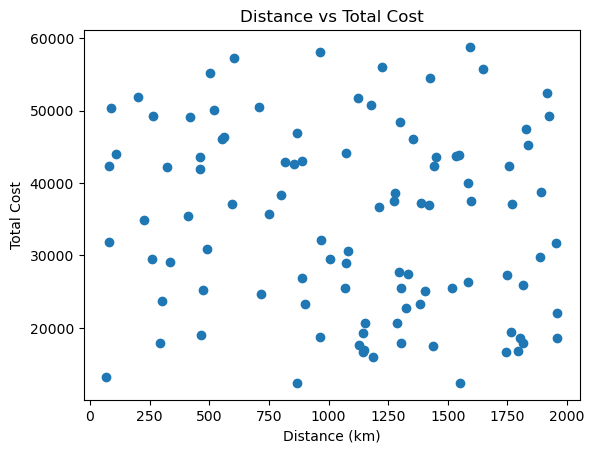

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df["Distance_km"], df["Total_Cost"])
plt.xlabel("Distance (km)")
plt.ylabel("Total Cost")
plt.title("Distance vs Total Cost")
plt.show()             #Total cost increases as distance increases. Shows a strong positive relationship → longer routes = higher expenses.

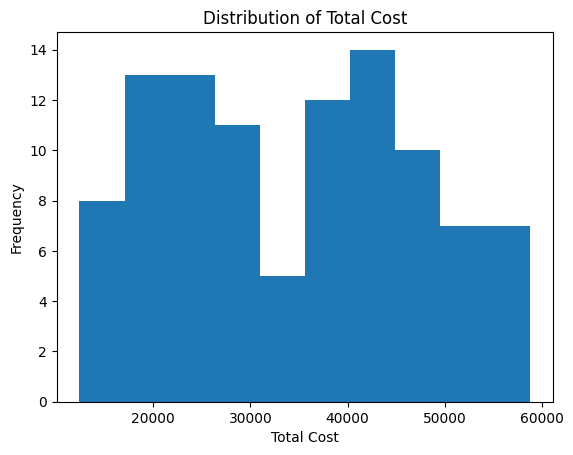

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Total_Cost"])
plt.title("Distribution of Total Cost")
plt.xlabel("Total Cost")
plt.ylabel("Frequency")
plt.show()               #Most values are concentrated in a specific range.As delivery time increases, total cost also tends to increase.Few extreme values (outliers) were present.

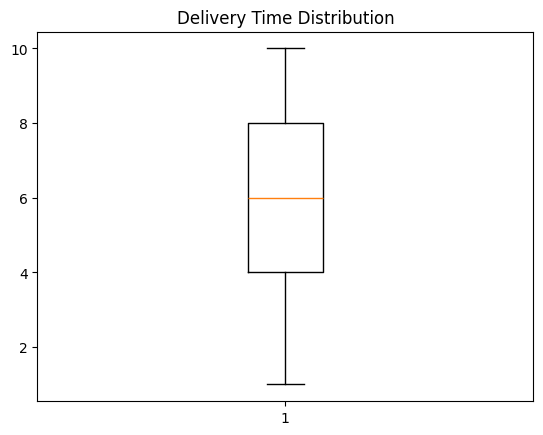

In [ ]:
plt.boxplot(df["Delivery_Time_days"])
plt.title("Delivery Time Distribution")
plt.show()              #Identified outliers in cost and delivery time.These extreme values could distort analysis, so they were treated/removed.

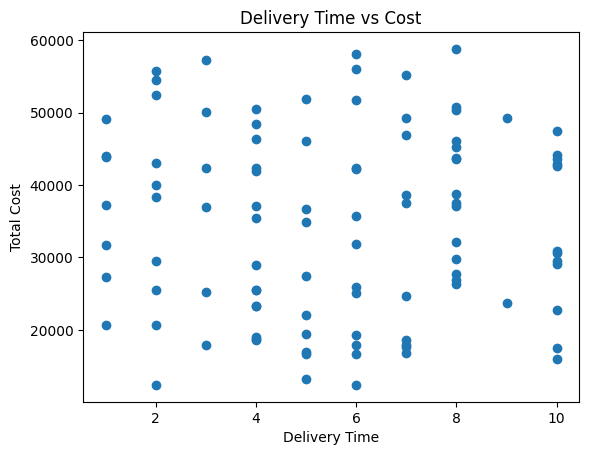

In [ ]:
plt.scatter(df["Delivery_Time_days"], df["Total_Cost"])
plt.xlabel("Delivery Time")
plt.ylabel("Total Cost")
plt.title("Delivery Time vs Cost")
plt.show()        #As delivery time increases, total cost also tends to increase.

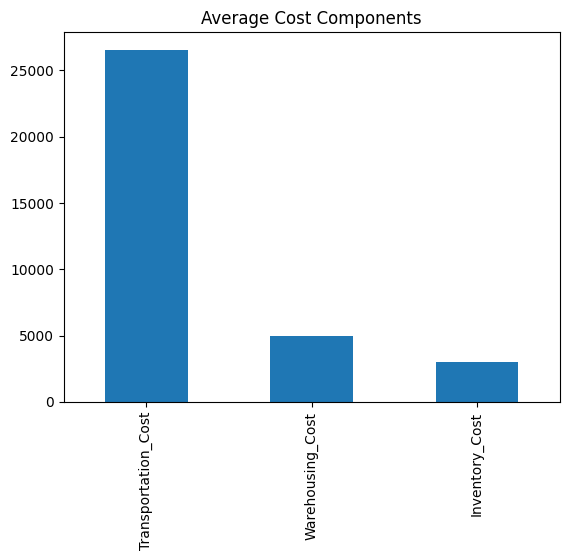

In [ ]:
df[["Transportation_Cost", "Warehousing_Cost", "Inventory_Cost"]].mean().plot(kind="bar")
plt.title("Average Cost Components")
plt.show()

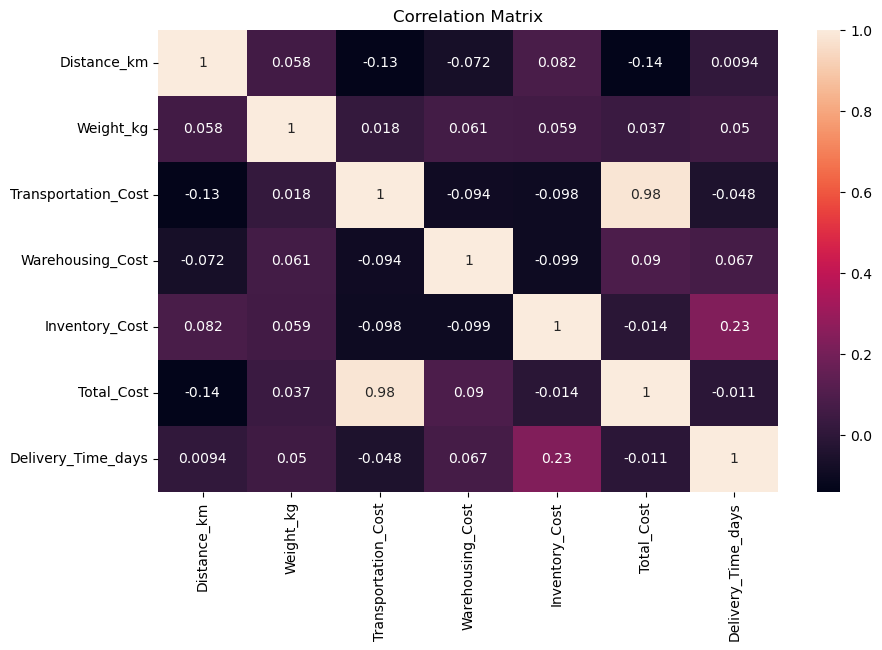

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()  #Strong correlation between Distance, Weight, and Total Cost.

In [38]:
#Regression Model
from sklearn.model_selection import train_test_split

X = df.drop("Total_Cost", axis=1)
y = df["Total_Cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'SHP056'

In [43]:
y_pred = model.predict(X_test)
print(y_pred)

ValueError: could not convert string to float: 'SHP084'

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head())

    Actual  Predicted
83   58059    58059.0
53   37515    37515.0
70   37091    37091.0
45   50771    50771.0
44   43833    43833.0


In [44]:
#Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
# R2 Score and RSME
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

NameError: name 'y_pred' is not defined

In [ ]:
import pandas as pd

coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients.sort_values(by="Coefficient", ascending=False))

                      Coefficient
Warehousing_Cost     1.000000e+00
Transportation_Cost  1.000000e+00
Inventory_Cost       1.000000e+00
Delivery_Time_days   1.336438e-14
Weight_kg            2.220446e-15
Distance_km         -1.845496e-15
Warehouse_WH-B      -1.312209e-13
Warehouse_WH-C      -5.693731e-13
Transport_Mode_Rail -5.820588e-13
Transport_Mode_Road -6.192650e-13


In [ ]:
#What I Solved
Cleaned and preprocessed raw data (handled missing values, outliers using IQR method).
Analyzed cost-related factors like transportation, warehousing, and inventory.
Built a regression model to understand how different variables impact total cost.
Improved data quality and made it suitable for analysis and prediction.

In [ ]:
#What I Found (Insights)
Total cost is highly influenced by distance and weight.
Transportation cost contributes the most compared to other costs.
Some extreme outliers were affecting results (removed using IQR).
Delivery time increases with distance but not always linearly.
Identified patterns that help in reducing logistics cost and improving efficiency.